# Spacehopper Gripper Data Evaluation\nThis notebook processes the raw ROS logs from the physical gripper tests on various rock surfaces. It trims the initial offsets, identifies the point of slippage (when Tangential Force Fx drops), and plots the Maximum Normal Force (Fz) vs Tangential Force prior to slippage. The calculated statistics are then used to evaluate the gripper's holding performance.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
def plot_forces(df, cut_1=0, cut_2=None, avg_end=None, fx_threshold=1, offset_position='beginning', offset_length=10):
    """
    Plots the Tangential Force (Fx) and Normal Force (Fz) from the given DataFrame with offsets
    and within a specified range.

    Parameters:
    df (pd.DataFrame): The DataFrame containing force data with columns 'Fx' and 'Fz'.
    cut_1 (int): The starting index for the range of data to be plotted.
    cut_2 (int or None): The ending index for the range of data to be plotted. If None, plot till the end.

    Returns:
    None
    """
    if offset_position == 'beginning':
        # Calculate the offsets as the average of the first 20 entries
        offset_x = df['Fx'][:offset_length].mean()
        offset_z = df['Fz'][:offset_length].mean()
    elif offset_position == 'end':
        # Calculate the offsets as the average of the last 20 entries
        offset_x = df['Fx'][-offset_length:].mean()
        offset_z = df['Fz'][-offset_length:].mean()
    else:
        raise ValueError("Invalid offset_position. Choose either 'beginning' or 'end'.")

    # If avg_end is not provided, use cut_2
    avg_end = avg_end if avg_end is not None else cut_2

    # If avg_end is not None, calculate the length from cut_1 to avg_end
    if avg_end is not None and cut_1 is not None:
        length_cut_to_avg = avg_end - cut_1
        print(f"Length from cut_1 to avg_end: {length_cut_to_avg}")

    # Calculate average values of Fx and Fz in the defined averaging interval
    avg_fx = df[cut_1:avg_end]['Fx'].mean() - offset_x
    avg_fz = df[cut_1:avg_end]['Fz'].mean() - offset_z

    # Apply the cut range to the DataFrame
    df_cut = df[cut_1:cut_2].copy()
    
    # Find the maximum Fz and corresponding timestep
    max_fz = df_cut['Fz'].max() - offset_z
    max_fz_timestep = df_cut['Fz'].idxmax()

    # Find the timestep where Fx drops below the threshold
    fx_drop_timestep = df_cut[df_cut['Fx'] - offset_x < fx_threshold].index.min()
    
    # Print the average values
    print(f"Average Fx in the averaging interval [{cut_1}:{avg_end}]: {avg_fx}")
    print(f"Average Fz in the averaging interval [{cut_1}:{avg_end}]: {avg_fz}")
    print(f"Maximum Fz in the plotting interval [{cut_1}:{cut_2}]: {max_fz} at timestep {max_fz_timestep}")
    print(f"Time step where Fx drops below {fx_threshold}: {fx_drop_timestep}")
    
    plt.figure(figsize=(10, 5))
    plt.plot(df_cut['Fx'] - offset_x, label='Tangential Force (Fx)', alpha=0.7)
    plt.plot(df_cut['Fz'] - offset_z, label='Normal Force (Fz)', alpha=0.7)
    plt.axvline(x=max_fz_timestep, color='r', linestyle='--', label='Max Fz', alpha=0.2)
    plt.axvline(x=fx_drop_timestep, color='g', linestyle='--', label=f'Fx < {fx_threshold}', alpha=0.2)
    plt.xlabel('Timesteps')
    plt.ylabel('Force (N)')
    plt.legend()
    plt.title('Tangential vs Normal Force (Offset Adjusted)')
    plt.grid()
    plt.show()

    # Apply the offsets to the cut DataFrame
    df_cut['Fx'] = df_cut['Fx'] - offset_x
    df_cut['Fz'] = df_cut['Fz'] - offset_z
    
    # Shift the index so it starts at 0 if cut_1 is not None
    if cut_1 is not None:
        df_cut.index = df_cut.index - cut_1

    # Return the modified DataFrame
    return df_cut, (length_cut_to_avg if avg_end is not None and cut_1 is not None else None)

In [3]:
def plot_modified_df(df_cut):
    """
    Plots the modified DataFrame with adjusted time steps.

    Parameters:
    df_cut (pd.DataFrame): The modified DataFrame with adjusted time steps.

    Returns:
    None
    """
    plt.figure(figsize=(10, 5))
    plt.plot(df_cut['Fx'], label='Tangential Force (Fx)', alpha=0.7)
    plt.plot(df_cut['Fz'], label='Normal Force (Fz)', alpha=0.7)
    plt.xlabel('Adjusted Timesteps')
    plt.ylabel('Force (N)')
    plt.legend()
    plt.title('Modified Tangential vs Normal Force (Adjusted Timesteps)')
    plt.grid()
    plt.show()

<font size="6">Sediment 40°</font>

<font size="6">Test 1: (worked)</font>

Length from cut_1 to avg_end: 811
Average Fx in the averaging interval [1465:2276]: 5.305054600955133
Average Fz in the averaging interval [1465:2276]: 2.047130233821093
Maximum Fz in the plotting interval [1465:None]: 3.86214599609375 at timestep 2260
Time step where Fx drops below 1: 2276


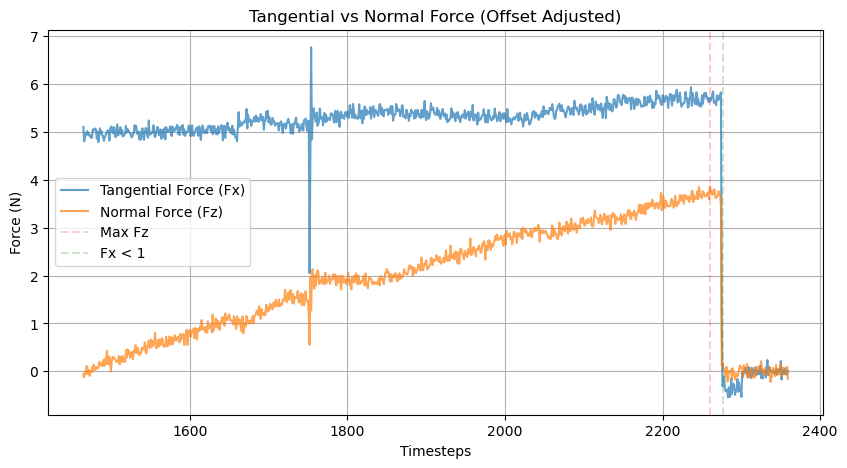

In [101]:
data = "../raw_data/Gripper Test Microspines Angles//Sediment_40_5N//log_202405241514.csv"
df = pd.read_csv(data)
test_1, end_1 = plot_forces(df, cut_1=1465, cut_2=None, avg_end=2276, offset_position='end', offset_length=15)

<font size="6">Test 2: (worked)</font>

Length from cut_1 to avg_end: 1234
Average Fx in the averaging interval [1315:2549]: 4.9338629257350535
Average Fz in the averaging interval [1315:2549]: 3.435573188373683
Maximum Fz in the plotting interval [1315:None]: 7.484588623046875 at timestep 2516
Time step where Fx drops below 1: 2549


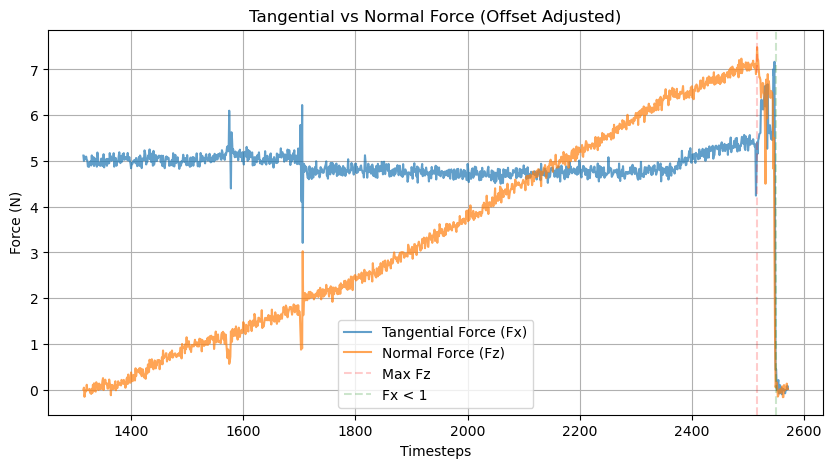

In [25]:
data = "../raw_data/Gripper Test Microspines Angles//Sediment_40_5N//log_202405241516.csv"
df = pd.read_csv(data)
test_2, end_2 = plot_forces(df, cut_1=1315, cut_2=None, avg_end=2549, offset_position='end', offset_length=10)

<font size="6">Test 3: (worked)</font>

Length from cut_1 to avg_end: 1322
Average Fx in the averaging interval [290:1612]: 5.512697234637077
Average Fz in the averaging interval [290:1612]: 2.1626437542598413
Maximum Fz in the plotting interval [290:None]: 4.576338704427084 at timestep 1575
Time step where Fx drops below 1: 1612


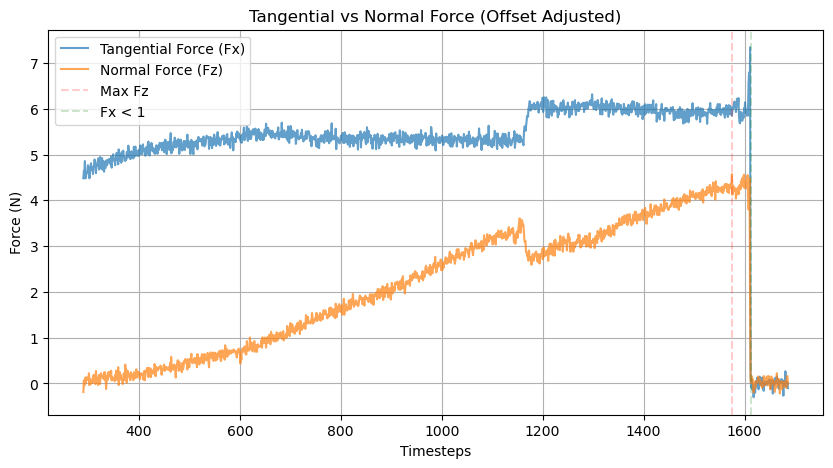

In [35]:
data = "../raw_data/Gripper Test Microspines Angles//Sediment_40_5N//log_202405241518.csv"
df = pd.read_csv(data)
test_3, end_3 = plot_forces(df, cut_1=290, cut_2=None, avg_end=1612, offset_position='end', offset_length=15)

<font size="6">Test 4: (worked)</font>

Length from cut_1 to avg_end: 861
Average Fx in the averaging interval [325:1186]: 5.129641820107881
Average Fz in the averaging interval [325:1186]: 1.0389737473686123
Maximum Fz in the plotting interval [325:None]: 2.4997762044270835 at timestep 1063
Time step where Fx drops below 1: 1060


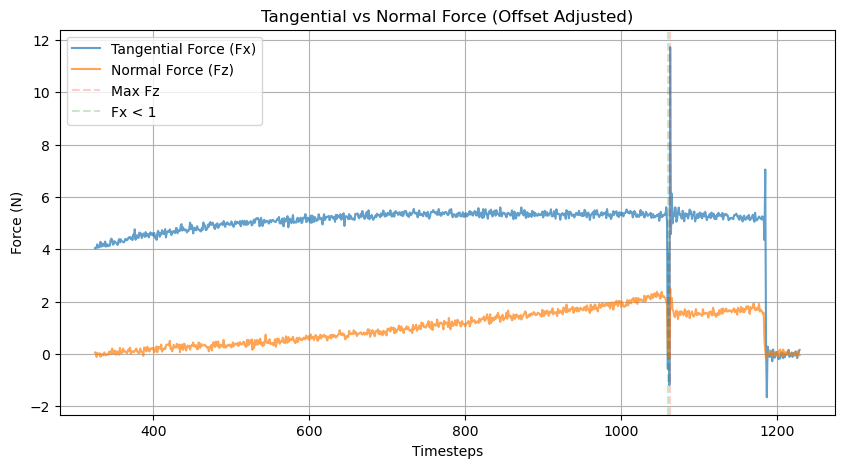

In [40]:
data = "../raw_data/Gripper Test Microspines Angles//Sediment_40_5N//log_202405241520.csv"
df = pd.read_csv(data)
test_4, end_4 = plot_forces(df, cut_1=325, cut_2=None, avg_end=1186, offset_position='end', offset_length=15)

<font size="6">Test 5: (worked)</font>

Length from cut_1 to avg_end: 766
Average Fx in the averaging interval [298:1064]: 5.535872918237698
Average Fz in the averaging interval [298:1064]: 0.8554927922208171
Maximum Fz in the plotting interval [298:None]: 1.8527058919270833 at timestep 1037
Time step where Fx drops below 1: 1064


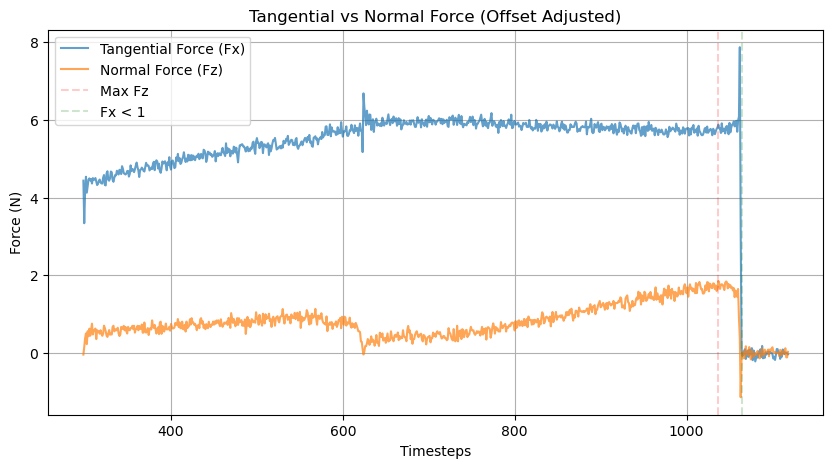

In [46]:
data = "../raw_data/Gripper Test Microspines Angles//Sediment_40_5N//log_202405241521.csv"
df = pd.read_csv(data)
test_5, end_5 = plot_forces(df, cut_1=298, cut_2=None, avg_end=1064, offset_position='end', offset_length=15)

<font size="6">Test 6: (worked)</font>

Length from cut_1 to avg_end: 638
Average Fx in the averaging interval [240:878]: 2.6885329905473077
Average Fz in the averaging interval [240:878]: 0.5952390537242033
Maximum Fz in the plotting interval [240:918]: 1.3577962239583332 at timestep 856
Time step where Fx drops below 1: 878


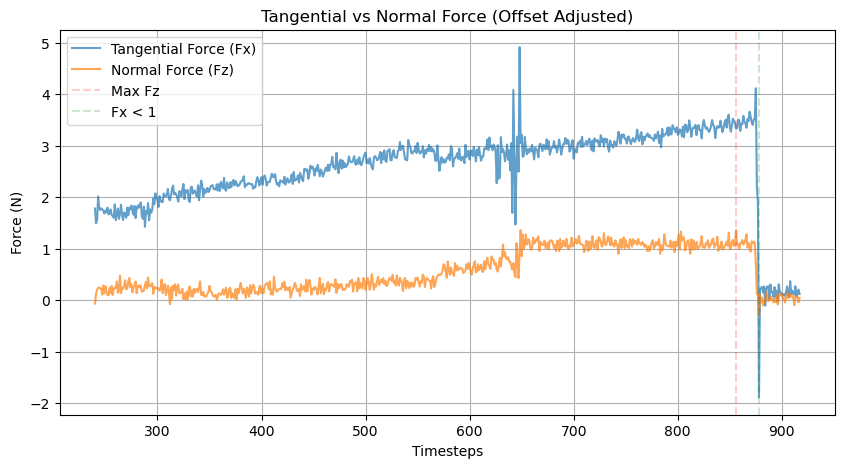

In [55]:
data = "../raw_data/Gripper Test Microspines Angles//Sediment_40_5N//log_202405241522.csv"
df = pd.read_csv(data)
test_6, end_6 = plot_forces(df, cut_1=240, cut_2=918, avg_end=878, offset_position='beginning', offset_length=15)

<font size="6">Test 7a: (worked)</font>

Length from cut_1 to avg_end: 284
Average Fx in the averaging interval [500:784]: 5.244533307451598
Average Fz in the averaging interval [500:784]: 0.7573417269567928
Maximum Fz in the plotting interval [500:799]: 1.4533406575520833 at timestep 767
Time step where Fx drops below 1: 784


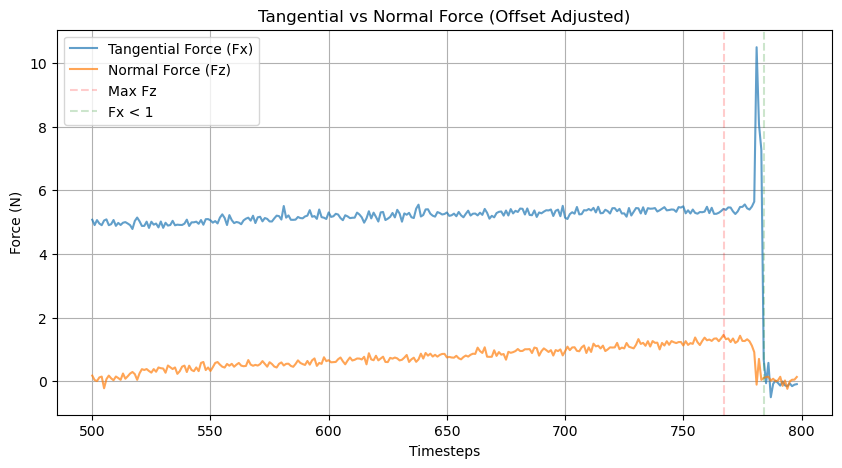

In [61]:
data = "../raw_data/Gripper Test Microspines Angles//Sediment_40_5N//log_202405241523.csv"
df = pd.read_csv(data)
test_7a, end_7a = plot_forces(df, cut_1=500, cut_2=799, avg_end=784, offset_position='beginning', offset_length=15)

<font size="6">Test 7b: (worked)</font>

Length from cut_1 to avg_end: 160
Average Fx in the averaging interval [1475:1635]: 4.458141317466895
Average Fz in the averaging interval [1475:1635]: 0.36296017964680993
Maximum Fz in the plotting interval [1475:None]: 0.7897542317708334 at timestep 1623
Time step where Fx drops below 1: 1635


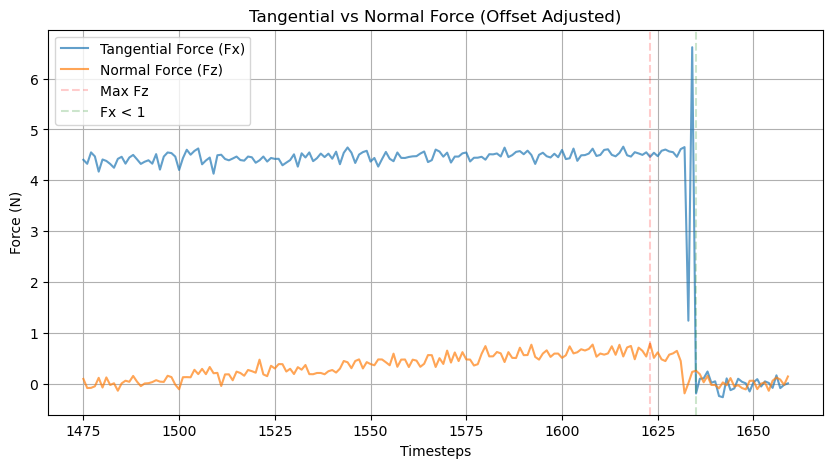

In [65]:
data = "../raw_data/Gripper Test Microspines Angles//Sediment_40_5N//log_202405241523.csv"
df = pd.read_csv(data)
test_7b, end_7b = plot_forces(df, cut_1=1475, cut_2=None, avg_end=1635, offset_position='end', offset_length=15)

<font size="6">Test 8: (worked)</font>

Length from cut_1 to avg_end: 442
Average Fx in the averaging interval [633:1075]: 5.568196467720366
Average Fz in the averaging interval [633:1075]: 1.2130871250618638
Maximum Fz in the plotting interval [633:None]: 2.56756591796875 at timestep 1068
Time step where Fx drops below 1: 1075


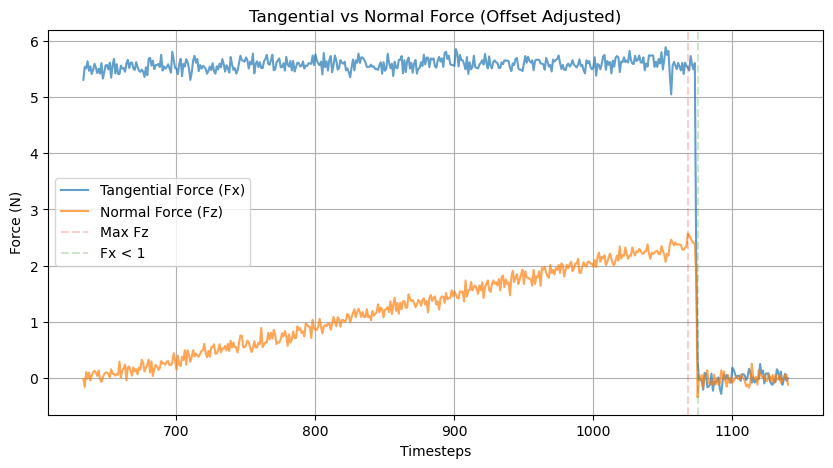

In [71]:
data = "../raw_data/Gripper Test Microspines Angles//Sediment_40_5N//log_202405241526.csv"
df = pd.read_csv(data)
test_8, end_8 = plot_forces(df, cut_1=633, cut_2=None, avg_end=1075, offset_position='end', offset_length=15)

<font size="6">Test 9: (worked)</font>

Length from cut_1 to avg_end: 593
Average Fx in the averaging interval [1300:1893]: 4.784667822107162
Average Fz in the averaging interval [1300:1893]: 1.5812816531957032
Maximum Fz in the plotting interval [1300:1915]: 2.6469278971354164 at timestep 1888
Time step where Fx drops below 1: 1893


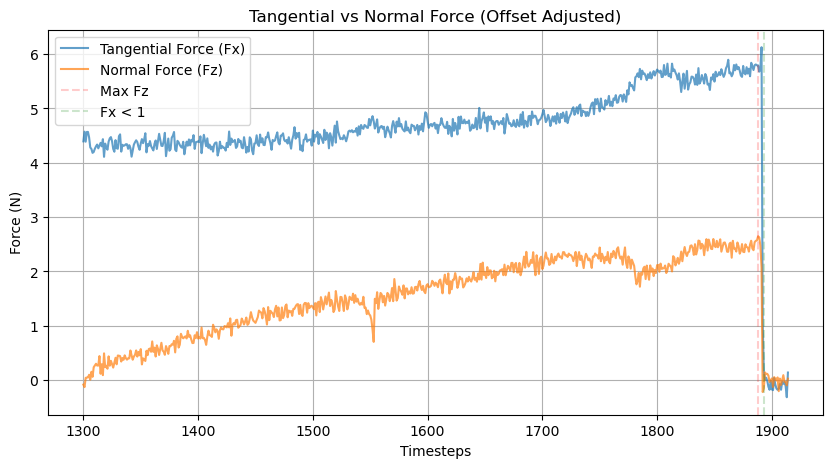

In [78]:
data = "../raw_data/Gripper Test Microspines Angles//Sediment_40_5N//log_202405241527.csv"
df = pd.read_csv(data)
test_9, end_9 = plot_forces(df, cut_1=1300, cut_2=1915, avg_end=1893, offset_position='end', offset_length=15)

<font size="6">Test 10: (worked)</font>

Length from cut_1 to avg_end: 978
Average Fx in the averaging interval [770:1748]: 5.695811247484328
Average Fz in the averaging interval [770:1748]: 2.4520312849485557
Maximum Fz in the plotting interval [770:None]: 4.3932861328125 at timestep 1673
Time step where Fx drops below 1: 922


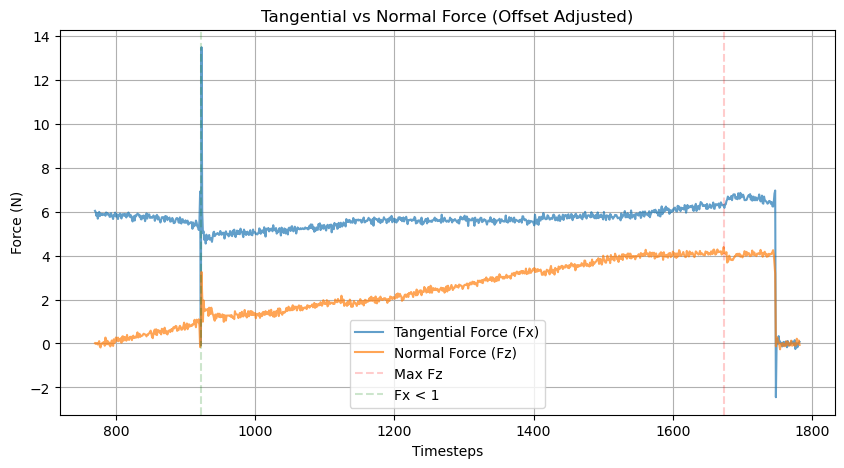

In [85]:
data = "../raw_data/Gripper Test Microspines Angles//Sediment_40_5N//log_202405241531.csv"
df = pd.read_csv(data)
test_10, end_10 = plot_forces(df, cut_1=770, cut_2=None, avg_end=1748, offset_position='end', offset_length=15)

In [102]:
def plot_multiple_tests(tests, ends):
    # Find the maximum length among all datasets
    max_length = max([end for end in ends if end is not None])
    
    plt.figure(figsize=(15, 7))
    
    for i, (test, end) in enumerate(zip(tests, ends)):
        if end is not None:
            fz_series = test['Fz']
            fz_series_cut = fz_series[:end]
            if len(fz_series_cut) < max_length:
                padded_fz = np.pad(fz_series_cut.values, (0, max_length - len(fz_series_cut)), 'constant', constant_values=np.nan)
            else:
                padded_fz = fz_series_cut.values
            plt.plot(padded_fz, label=f'Dataset {i+1} Fz', alpha=0.6)
        
    plt.xlabel('Adjusted Timesteps')
    plt.ylabel('Normal Force (Fz) (N)')
    plt.legend()
    plt.title('Normal Force (Fz) of Multiple Datasets')
    plt.grid()
    plt.show()

In [103]:
def calculate_statistics(tests, ends):
    max_fz_values = []
    avg_fz_values = []
    avg_fx_values = []
    
    for test, end in zip(tests, ends):
        if end is not None:
            fz_series = test['Fz']
            fx_series = test['Fx']
            fz_series_cut = fz_series[:end]
            fx_series_cut = fx_series[:end]
            max_fz_values.append(fz_series_cut.max())
            avg_fz_values.append(fz_series_cut.mean())
            avg_fx_values.append(fx_series_cut.mean())
    
    average_max_fz = np.mean(max_fz_values)
    std_max_fz = np.std(max_fz_values)
    
    average_avg_fz = np.mean(avg_fz_values)
    std_avg_fz = np.std(avg_fz_values)
    
    average_avg_fx = np.mean(avg_fx_values)
    std_avg_fx = np.std(avg_fx_values)
    
    print(f"Average of maximum Fz forces: {average_max_fz}")
    print(f"Standard deviation of maximum Fz forces: {std_max_fz}")
    print(f"Average of average Fz forces: {average_avg_fz}")
    print(f"Standard deviation of average Fz forces: {std_avg_fz}")
    print(f"Average of average Fx forces: {average_avg_fx}")
    print(f"Standard deviation of average Fx forces: {std_avg_fx}")
    
    # Create a dictionary to store the statistics
    statistics_dict = {
        'Statistic': ['Average Max Fz', 'Std Max Fz', 'Average Avg Fz', 'Std Avg Fz', 'Average Avg Fx', 'Std Avg Fx'],
        'Value': [average_max_fz, std_max_fz, average_avg_fz, std_avg_fz, average_avg_fx, std_avg_fx]
    }
    
    # Convert the dictionary to a DataFrame
    statistics_df = pd.DataFrame(statistics_dict)
    
    # Save the statistics to a CSV file
    statistics_df.to_csv("../raw_data/Gripper Test Microspines Angles//40//Sediment_40_stats.csv", index=False)

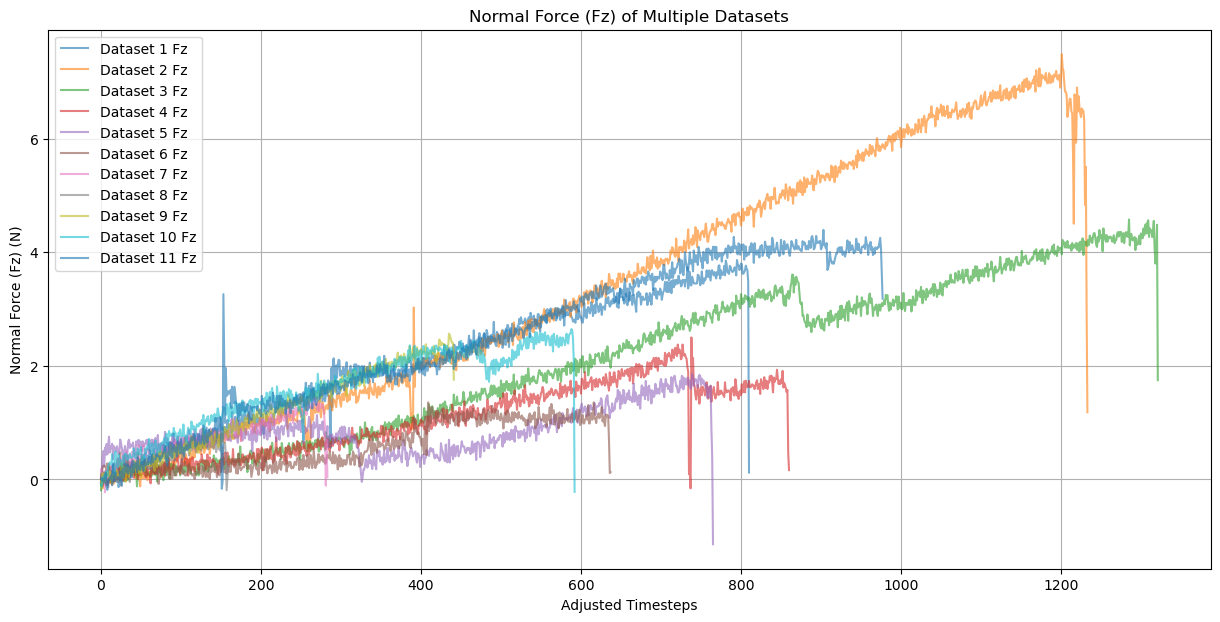

Average of maximum Fz forces: 3.044020589192708
Standard deviation of maximum Fz forces: 1.8367943008826377
Average of average Fz forces: 1.500159521779816
Standard deviation of average Fz forces: 0.892957739909838
Average of average Fx forces: 4.987001150222773
Standard deviation of average Fx forces: 0.80971681708096


In [104]:
tests = [test_1, test_2, test_3, test_4, test_5, test_6, test_7a, test_7b, test_8, test_9, test_10]
ends = [end_1, end_2, end_3, end_4, end_5, end_6, end_7a, end_7b, end_8, end_9, end_10]
plot_multiple_tests(tests, ends)
calculate_statistics(tests, ends)

In [105]:
def save_tests_to_csv_cut(tests, ends, file_prefix="../raw_data/Gripper Test Microspines Angles//40//Sediment_40"):
    # Save each test dataset to a separate CSV file, cutting at the end point
    for i, (test, end) in enumerate(zip(tests, ends)):
        test_cut = test.iloc[:end] if end is not None else test  # Cut the test data at the end point
        test_cut.to_csv(f'{file_prefix}_{i+1}.csv', index=False)

save_tests_to_csv_cut(tests, ends)